# Single logical qubit in ITensor

Rotated Planar Surface Code. 
ITensor for numerical simulation.

## What this notebook does

1. Create physical qubit layout for rotated planar surface code and create snake ordering for Itensor mps train.
2. Measure X-stabilizers and Z-stabilizers.
3. Demo for detecting simple errors

## Conventions

- `"Up"` $= |0\rangle$, `"Dn"` $= |1\rangle$. All qubits initialised to `"Up"`.
- Measurement outcome `bit = 0` ⇔ aux ended in `Up` ⇔ no defect; `bit = 1` ⇔ defect.

## Layout

A *staggered* boundary placement is used here to avoid an anti-commutation
conflict the original `example.ipynb` layout has at the $(0,0)$ corner (left
and bottom aux there are different types but share a single data qubit).

| side   | aux positions                            | type |
|--------|-----------------------------------------:|:----:|
| left   | $(-0.5, y+0.5)$ for $y \in \{1,3\}$       | Z    |
| right  | $(d-0.5,\, y+0.5)$ for $y \in \{0,2\}$    | Z    |
| bottom | $(x+0.5,\, -0.5)$ for $x \in \{0,2\}$     | X    |
| top    | $(x+0.5,\, d-0.5)$ for $x \in \{1,3\}$    | X    |

Bulk aux at $(x+0.5, y+0.5)$ for $x,y \in \{0,\dots,d-2\}$: **Z** if $x+y$
even, **X** if $x+y$ odd. The X-type "open" boundaries are *top* and *bottom*
(an X chain reaching either disappears undetected); the Z-type boundaries are
*left* and *right*.

In [1]:
using ITensors, ITensorMPS, LinearAlgebra, Random, Plots
Random.seed!(42)
threshold = 1e-8;

## 1. Geometry and snake ordering (same as `example.ipynb`)

In [21]:
dis = 5
data_qubits = dis^2
aux_qubits  = dis^2 - 1
total_qubits = data_qubits + aux_qubits

data_coords = [(x, y) for x in 0:(dis-1), y in 0:(dis-1)]
data_list   = vec(data_coords)

x_aux_coords = [
    if isodd(y)
        (x + 1.5, y + 0.5)
    else
        (x + 0.5, y + 0.5)
    end
    for x in 0:2:(dis-2), y in 0:(dis-2)
]
z_aux_coords = [
    if iseven(y)
        (x + 1.5, y + 0.5)
    else
        (x + 0.5, y + 0.5)
    end
    for x in 0:2:(dis-2), y in 0:(dis-2)
]
x_aux_list   = vec(x_aux_coords)
z_aux_list   = vec(z_aux_coords)

z_aux_list   = [z_aux_list; [(-0.5, y + 0.5)    for y in 0:2:(dis-2)]]
x_aux_list   = [x_aux_list; [(x + 1.5, -0.5)    for x in 0:2:(dis-2)]]
z_aux_list   = [z_aux_list; [(dis - 0.5, y + 0.5) for y in 1:2:(dis-2)]]
x_aux_list   = [x_aux_list; [(x + 0.5, dis - 0.5) for x in 0:2:(dis-2)]]
aux_list   = [x_aux_list; z_aux_list]

all_sites_coords = vcat(data_list, aux_list)

function snake_order(coords)
    sort(coords, lt=(a, b) -> begin
        row_a = Int(round(2a[2]))
        row_b = Int(round(2b[2]))
        if row_a != row_b
            row_a < row_b
        else
            iseven(row_a) ? a[1] < b[1] : a[1] > b[1]
        end
    end)
end

snake_sites = snake_order(all_sites_coords)
println("Total qubits = ", length(snake_sites))

Total qubits = 49


### Plot Geometry

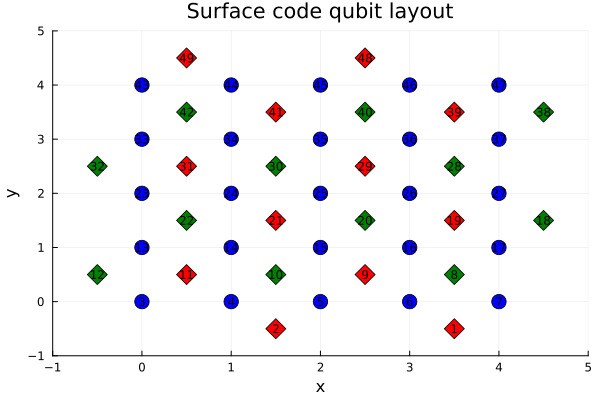

In [24]:
function plot_geometry(data_coords, x_aux_list, z_aux_list, snake_sites)
    data_x = [p[1] for p in data_coords]
    data_y = [p[2] for p in data_coords]

    x_aux_x = [p[1] for p in x_aux_list]
    x_aux_y = [p[2] for p in x_aux_list]

    z_aux_x = [p[1] for p in z_aux_list]
    z_aux_y = [p[2] for p in z_aux_list]

    p = scatter(
        data_x, data_y;
        label="data qubits",
        color=:blue,
        marker=:circle,
        markersize=8,
        legend=false,
    )

    scatter!(
        x_aux_x, x_aux_y;
        label="X aux qubits",
        color=:red,
        marker=:diamond,
        markersize=10,
        legend=false,
    )

    scatter!(
        z_aux_x, z_aux_y;
        label="Z aux qubits",
        color=:green,
        marker=:diamond,
        markersize=10,
        legend=false,
    )

    axisratio = :equal
    xlabel!("x")
    ylabel!("y")
    title!("Surface code qubit layout")
    xlims!(-1, 5)
    ylims!(-1, 5)

    for (i, (x, y)) in enumerate(snake_sites)
        annotate!(x, y, text(string(i), 8, :black))
    end

    display(p)

end

plot_geometry(data_coords, x_aux_list, z_aux_list, snake_sites)

In [25]:
sites = siteinds("S=1/2", total_qubits)
site_by_coord = Dict(coord => sites[i] for (i, coord) in enumerate(snake_sites))

function data_neighbors(aux_coord, data_coords)
    [d for d in data_coords
       if abs(d[1] - aux_coord[1]) == 0.5 && abs(d[2] - aux_coord[2]) == 0.5]
end

# Helper: parse the global site index from an Index's tags (e.g. "n=37").
function site_n(s)
    for t in tags(s)
        ts = String(t)
        if startswith(ts, "n=")
            return parse(Int, ts[3:end])
        end
    end
    error("no n= tag on site")
end;

## 2. Measurement helpers

The measurement convention used here:

- `Sz` on a spin-½ has eigenvalues $\pm\tfrac12$. Identify the spin-up
  outcome ($S^z=+\tfrac12$) with classical bit `1`, spin-down with `0`. So
  $P(\text{bit}=1) = \tfrac12 + \langle S^z\rangle$.
- For an auxiliary that begins in `"Up"` (=$|0\rangle$), an *uncorrupted*
  Z-syndrome reads `0`; an *uncorrupted* X-syndrome on $|+\rangle_L$ also reads
  `0`. So "syndrome = 0" $\Leftrightarrow$ "+1 eigenvalue of the stabilizer".

In [26]:
# Projectors onto Up / Dn of a single site, expressed via Sz:
#   P_up = (I/2) + Sz   ->  diag(1, 0)   in (Up, Dn) basis
#   P_dn = (I/2) - Sz   ->  diag(0, 1)
P_up(s) = 0.5 * op("Id", s) + op("Sz", s)
P_dn(s) = 0.5 * op("Id", s) - op("Sz", s)

# Simulate a projective Z-measurement on `aux_site` of MPS `psi`.
# Returns (bit, psi_post) where bit==1 means Up (Sz=+1/2), bit==0 means Dn.
function measure_Z!(psi, aux_site; cutoff = threshold)
    sz = real(inner(psi', apply(op("Sz", aux_site), psi; cutoff)))
    p_up = 0.5 + sz                       # probability of outcome "Up" = bit 1
    if rand() < p_up
        psi = apply(P_up(aux_site), psi; cutoff)
        bit = 0
    else
        psi = apply(P_dn(aux_site), psi; cutoff)
        bit = 1
    end
    psi = psi / sqrt(real(inner(psi, psi)))   # renormalize after projection
    return bit, psi
end;

## 3. Stabilizer-measurement circuits

Using the CNOT orders from Fig. 2(a) of the paper (X-type and Z-type each have
their own valid order).

In [28]:
# Apply one X-type stabilizer measurement at aux_coord; mutates psi via projection.
# Circuit: H_aux -> CNOTs(aux -> data) -> H_aux -> measure Z_aux.
function measure_X_stab(psi, aux_coord; cutoff = threshold)
    aux_site = site_by_coord[aux_coord]

    psi = apply(op("H", aux_site), psi; cutoff)

    nbrs = data_neighbors(aux_coord, data_list)
    order = length(nbrs) == 4 ? [2, 1, 4, 3] : [1, 2]
    for data_coord in nbrs[order]
        data_site = site_by_coord[data_coord]
        psi = apply(op("CNOT", aux_site, data_site), psi; cutoff)
    end

    psi = apply(op("H", aux_site), psi; cutoff)

    bit, psi = measure_Z!(psi, aux_site; cutoff)
    return bit, psi
end

# Z-type stabilizer measurement (this one was already correct in the original).
# Circuit: CNOTs(data -> aux) -> measure Z_aux.
function measure_Z_stab(psi, aux_coord; cutoff = threshold)
    aux_site = site_by_coord[aux_coord]

    nbrs = data_neighbors(aux_coord, data_list)
    order = length(nbrs) == 4 ? [2, 4, 1, 3] : [1, 2]
    for data_coord in nbrs[order]
        data_site = site_by_coord[data_coord]
        psi = apply(op("CNOT", data_site, aux_site), psi; cutoff)
    end

    bit, psi = measure_Z!(psi, aux_site; cutoff)
    return bit, psi
end;

## 4. Test A — |0⟩ data initialization

Z-stabilizers should all read `0` deterministically. X-stabilizers will each be
random 50/50 — **this is the correct physics**, not a bug. Together, the
X-syndrome pattern from this first round *defines* which logical-|0⟩
representative the state has been projected into.

In [29]:
psi0 = MPS(sites, "Up");   # |0...0> in the qubit convention

## Add Error

In [ ]:
psi_error = copy(psi0)
# Error at site i
psi_error = apply(op("X", site_by_coord[data_list[1]]), psi_error; cutoff=threshold);
# psi_error = apply(op("X", sites[14]), psi_error; cutoff=threshold);

In [32]:


# Z-stabilizers first (they commute with each other and with the X-stabs we'll
# measure after, so order between Z and X doesn't matter at this stage).
SyndromeZ = Dict{Int,Int}()
psi = copy(psi_error)
for aux_coord in z_aux_list
    bit, psi = measure_Z_stab(psi, aux_coord; cutoff=threshold)
    SyndromeZ[site_n(site_by_coord[aux_coord])] = bit
end

println("Z syndromes (should all be 0):")
println(sort(collect(SyndromeZ)))
println("nonzero Z syndromes: ", count(==(1), values(SyndromeZ)))

Z syndromes (should all be 0):
[8 => 0, 10 => 0, 12 => 0, 18 => 0, 20 => 0, 22 => 0, 28 => 0, 30 => 0, 32 => 0, 38 => 0, 40 => 0, 42 => 0]
nonzero Z syndromes: 0


In [33]:
# Now X-stabilizers on the SAME state (post Z-measurement).
SyndromeX_run1 = Dict{Int,Int}()
psi_after_round1 = copy(psi)
for aux_coord in x_aux_list
    bit, psi_after_round1 = measure_X_stab(psi_after_round1, aux_coord; cutoff=threshold)
    SyndromeX_run1[site_n(site_by_coord[aux_coord])] = bit
end

println("X syndromes, round 1 (expected: random ~50/50):")
println(sort(collect(SyndromeX_run1)))
println("fraction of 1s: ",
        round(count(==(1), values(SyndromeX_run1)) / length(SyndromeX_run1); digits=3))

X syndromes, round 1 (expected: random ~50/50):
[1 => 0, 2 => 1, 9 => 0, 11 => 0, 19 => 1, 21 => 0, 29 => 1, 31 => 0, 39 => 0, 41 => 0, 48 => 0, 49 => 0]
fraction of 1s: 0.25


### Round 2 of X-stabilizers — should match round 1 exactly

After the first round projected the state onto a joint eigenstate of all the
X-stabilizers, a second round (with no errors) must reproduce the same
outcomes. The *detectors* (round-2 ⊕ round-1) should all be 0. This is what's
deterministic about the surface code in the absence of noise.

In [ ]:
SyndromeX_run2 = Dict{Int,Int}()
psi2 = copy(psi_after_round1)
for aux_coord in x_aux_list
    # Reset the aux to |0> (= Up). The aux was just measured, so we project to
    # Up if the outcome was 1, or leave at Dn if outcome was 0; either way we
    # then flip-to-Up by applying X when needed.
    aux_site = site_by_coord[aux_coord]
    # if SyndromeX_run1[site_n(aux_site)] == 1
    #     psi2 = apply(op("X", aux_site), psi2; cutoff=threshold)   # |1> -> |0>
    # end
    bit, psi2 = measure_X_stab(psi2, aux_coord)
    # Can do this "feedforward" correction in software after the fact,
    if SyndromeX_run1[site_n(aux_site)] == 1
        bit = xor(bit, SyndromeX_run1[site_n(aux_site)])
    end
    SyndromeX_run2[site_n(aux_site)] = bit
end

detectors = Dict(k => xor(SyndromeX_run2[k], SyndromeX_run1[k])
                 for k in keys(SyndromeX_run1))
println("Detectors (round2 XOR round1) — must all be 0:")
println(sort(collect(detectors)))
println("any nonzero? ", any(==(1), values(detectors)))

Detectors (round2 XOR round1) — must all be 0:
[1 => 0, 2 => 1, 9 => 0, 11 => 0, 19 => 1, 21 => 0, 29 => 1, 31 => 0, 39 => 0, 41 => 0, 48 => 0, 49 => 0]
any nonzero? true
